Dataset shape: (200, 5)

First few rows:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


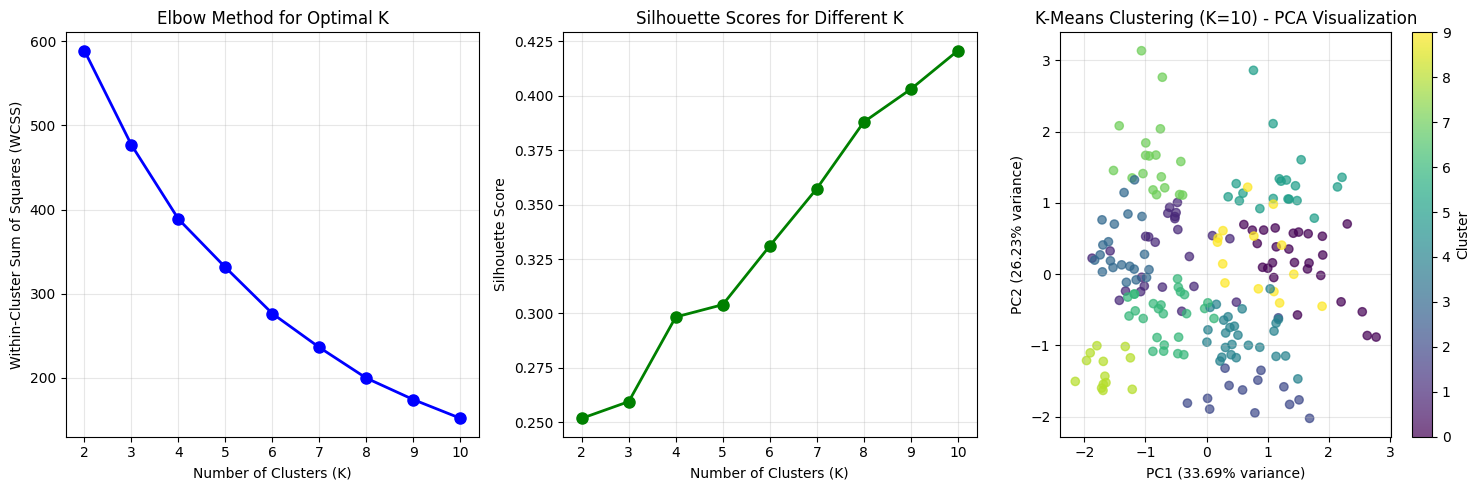


Cluster distribution:
Cluster
0    26
1    24
2    14
3    21
4    26
5    19
6    25
7    18
8    13
9    14
Name: count, dtype: int64

Cluster characteristics (mean values):
           Gender        Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                                 
0        1.000000  58.846154           48.692308               39.846154
1        1.000000  25.250000           41.250000               60.916667
2        0.071429  41.214286           26.071429               20.142857
3        0.000000  32.190476           86.047619               81.666667
4        0.000000  54.153846           54.230769               48.961538
5        1.000000  38.473684           85.894737               14.210526
6        0.000000  27.960000           57.360000               47.120000
7        1.000000  33.277778           87.111111               82.666667
8        0.000000  25.461538           25.692308               80.538462
9        0.000000  4

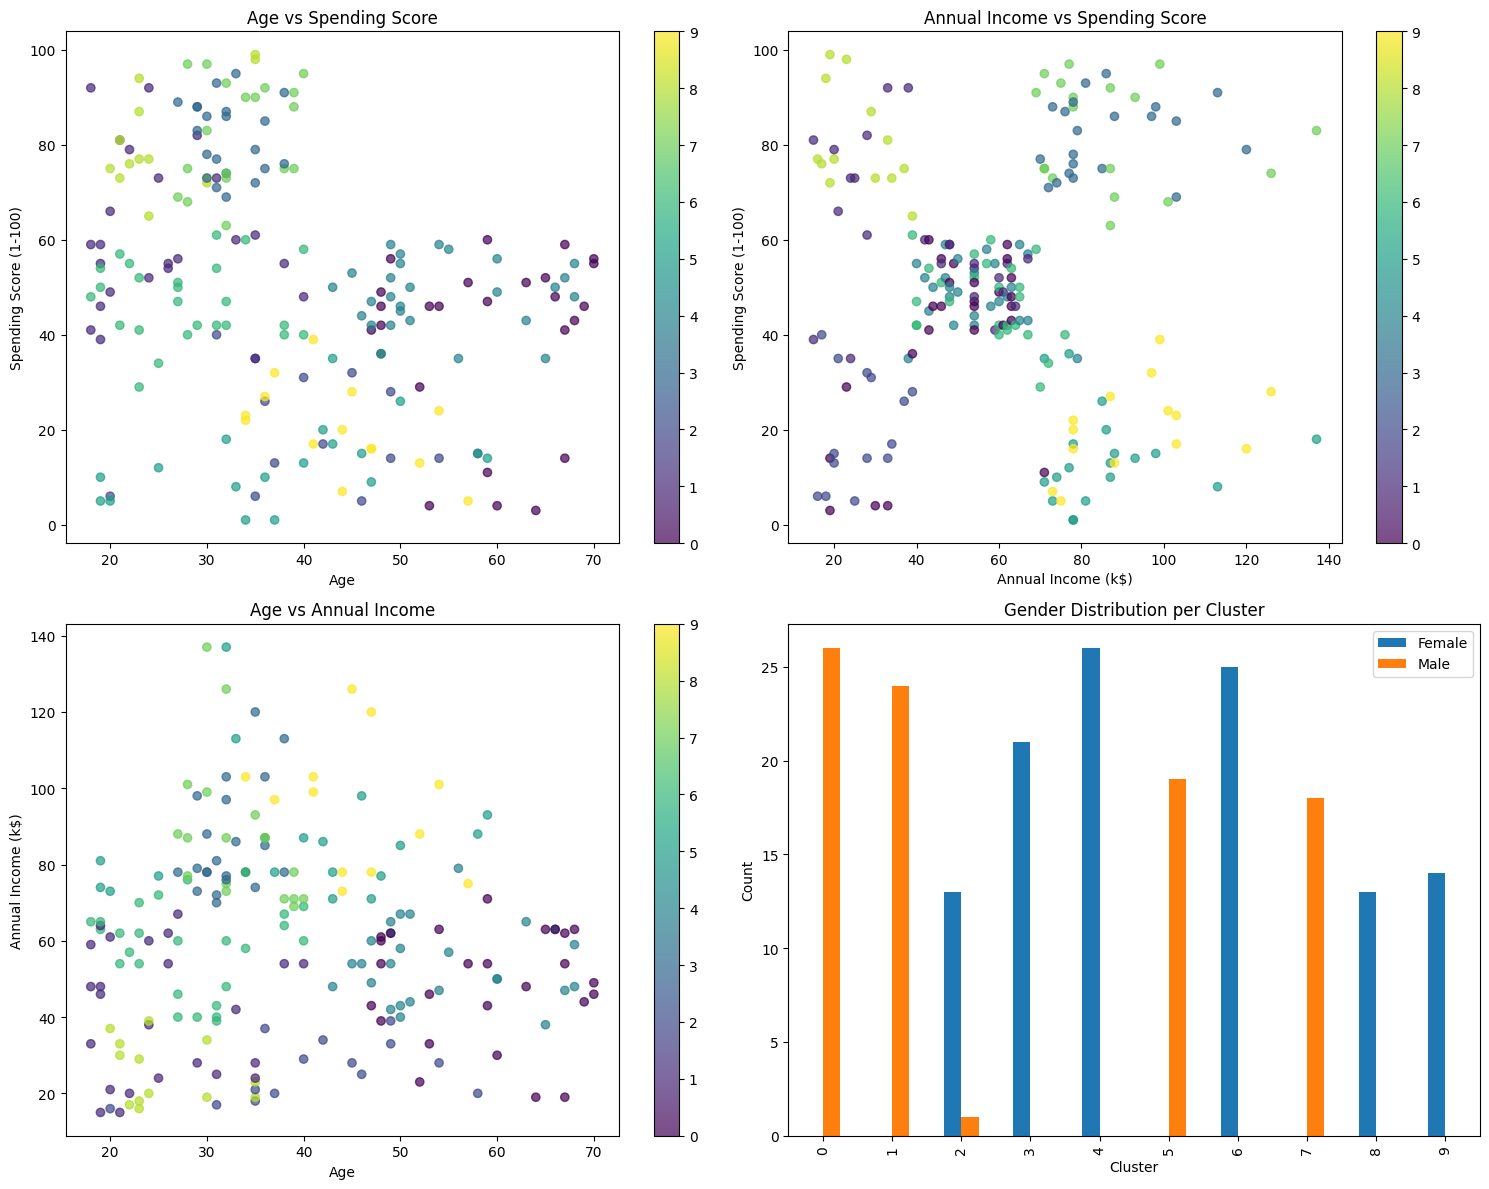


Final Clustering Evaluation:
Optimal K: 10
Silhouette Score: 0.421
WCSS: 152.03

Cluster Interpretation:

Cluster 0 (n=26):
  Average Age: 58.8
  Average Annual Income: $48.7k
  Average Spending Score: 39.8
  Gender Ratio (F/M): 0/26

Cluster 1 (n=24):
  Average Age: 25.2
  Average Annual Income: $41.2k
  Average Spending Score: 60.9
  Gender Ratio (F/M): 0/24

Cluster 2 (n=14):
  Average Age: 41.2
  Average Annual Income: $26.1k
  Average Spending Score: 20.1
  Gender Ratio (F/M): 13/1

Cluster 3 (n=21):
  Average Age: 32.2
  Average Annual Income: $86.0k
  Average Spending Score: 81.7
  Gender Ratio (F/M): 21/0

Cluster 4 (n=26):
  Average Age: 54.2
  Average Annual Income: $54.2k
  Average Spending Score: 49.0
  Gender Ratio (F/M): 26/0

Cluster 5 (n=19):
  Average Age: 38.5
  Average Annual Income: $85.9k
  Average Spending Score: 14.2
  Gender Ratio (F/M): 0/19

Cluster 6 (n=25):
  Average Age: 28.0
  Average Annual Income: $57.4k
  Average Spending Score: 47.1
  Gender Ratio (F/

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# Step 1: Load and explore the dataset
df = pd.read_csv('Mall_Customers.csv')
print("Dataset shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nDataset info:")
print(df.info())
print("\nBasic statistics:")
print(df.describe())

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())

# Step 2: Preprocess the data
# Convert Gender to numerical (0 for Female, 1 for Male)
df['Gender'] = df['Gender'].map({'Female': 0, 'Male': 1})

# Select features for clustering (excluding CustomerID)
features = ['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']
X = df[features]

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\nFeatures used for clustering: {features}")
print(f"Scaled data shape: {X_scaled.shape}")

# Step 3: Optional PCA for 2D visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"\nPCA explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {sum(pca.explained_variance_ratio_):.2f}")

# Step 4: Elbow Method to find optimal K
wcss = []  # Within-Cluster Sum of Square
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
    
    # Calculate silhouette score
    silhouette_avg = silhouette_score(X_scaled, kmeans.labels_)
    silhouette_scores.append(silhouette_avg)
    print(f"K={k}, WCSS={kmeans.inertia_:.2f}, Silhouette Score={silhouette_avg:.3f}")

# Plot Elbow Method
plt.figure(figsize=(15, 5))

# Subplot 1: Elbow Curve
plt.subplot(1, 3, 1)
plt.plot(k_range, wcss, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.title('Elbow Method for Optimal K')
plt.grid(True, alpha=0.3)

# Subplot 2: Silhouette Scores
plt.subplot(1, 3, 2)
plt.plot(k_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores for Different K')
plt.grid(True, alpha=0.3)

# Find optimal K based on silhouette score
optimal_k = k_range[np.argmax(silhouette_scores)]
print(f"\nOptimal K based on silhouette score: {optimal_k}")

# Step 5: Fit K-Means with optimal K
kmeans_optimal = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans_optimal.fit_predict(X_scaled)

# Add cluster labels to original dataframe
df['Cluster'] = cluster_labels

# Step 6: Visualize clusters using PCA
plt.subplot(1, 3, 3)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='viridis', alpha=0.7)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.title(f'K-Means Clustering (K={optimal_k}) - PCA Visualization')
plt.colorbar(scatter, label='Cluster')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Step 7: Analyze cluster characteristics
print(f"\nCluster distribution:")
print(df['Cluster'].value_counts().sort_index())

# Cluster analysis
cluster_analysis = df.groupby('Cluster')[features].mean()
print(f"\nCluster characteristics (mean values):")
print(cluster_analysis)

# Step 8: Additional visualization - Feature pairs
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Age vs Spending Score
scatter1 = axes[0,0].scatter(df['Age'], df['Spending Score (1-100)'], 
                            c=df['Cluster'], cmap='viridis', alpha=0.7)
axes[0,0].set_xlabel('Age')
axes[0,0].set_ylabel('Spending Score (1-100)')
axes[0,0].set_title('Age vs Spending Score')
plt.colorbar(scatter1, ax=axes[0,0])

# Annual Income vs Spending Score
scatter2 = axes[0,1].scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], 
                            c=df['Cluster'], cmap='viridis', alpha=0.7)
axes[0,1].set_xlabel('Annual Income (k$)')
axes[0,1].set_ylabel('Spending Score (1-100)')
axes[0,1].set_title('Annual Income vs Spending Score')
plt.colorbar(scatter2, ax=axes[0,1])

# Age vs Annual Income
scatter3 = axes[1,0].scatter(df['Age'], df['Annual Income (k$)'], 
                            c=df['Cluster'], cmap='viridis', alpha=0.7)
axes[1,0].set_xlabel('Age')
axes[1,0].set_ylabel('Annual Income (k$)')
axes[1,0].set_title('Age vs Annual Income')
plt.colorbar(scatter3, ax=axes[1,0])

# Gender distribution per cluster
gender_cluster = pd.crosstab(df['Cluster'], df['Gender'])
gender_cluster.plot(kind='bar', ax=axes[1,1])
axes[1,1].set_xlabel('Cluster')
axes[1,1].set_ylabel('Count')
axes[1,1].set_title('Gender Distribution per Cluster')
axes[1,1].legend(['Female', 'Male'])

plt.tight_layout()
plt.show()

# Step 9: Final evaluation
final_silhouette = silhouette_score(X_scaled, cluster_labels)
print(f"\nFinal Clustering Evaluation:")
print(f"Optimal K: {optimal_k}")
print(f"Silhouette Score: {final_silhouette:.3f}")
print(f"WCSS: {kmeans_optimal.inertia_:.2f}")

# Step 10: Interpret clusters
print(f"\nCluster Interpretation:")
for cluster in range(optimal_k):
    cluster_data = df[df['Cluster'] == cluster]
    print(f"\nCluster {cluster} (n={len(cluster_data)}):")
    print(f"  Average Age: {cluster_data['Age'].mean():.1f}")
    print(f"  Average Annual Income: ${cluster_data['Annual Income (k$)'].mean():.1f}k")
    print(f"  Average Spending Score: {cluster_data['Spending Score (1-100)'].mean():.1f}")
    print(f"  Gender Ratio (F/M): {len(cluster_data[cluster_data['Gender']==0])}/{len(cluster_data[cluster_data['Gender']==1])}")

# Save the results
df.to_csv('Mall_Customers_Clustered.csv', index=False)
print(f"\nResults saved to 'Mall_Customers_Clustered.csv'")